# Application: verification qualitative d'un plan robotique

Ce notebook applique le raisonneur RCC8 a un probleme de planification robotique simple.

Objectif: verifier qu'un chemin propose pour un robot est coherent avec des contraintes spatiales qualitatives:

- le chemin doit rester dans une zone sure;
- le depart et l'objectif doivent toucher le chemin;
- les obstacles peuvent etre dans la zone sure, mais ne doivent pas intersecter le chemin;
- les zones interdites doivent etre evitees;
- les positions contradictoires avec la zone sure doivent etre refusees.

In [1]:
from matplotlib import pyplot as plt
from matplotlib.patches import Circle, Rectangle

from rcc8.rcc8solver import RCC8Solver
from rcc8.relations import ALL_RELATIONS

RELATION_ORDER = ["DC", "EC", "PO", "EQ", "TPP", "NTPP", "TPPI", "NTPPI"]


def build_solver(regions):
    constraints = {}
    for i in regions:
        for j in regions:
            if i != j:
                constraints[(i, j)] = set(ALL_RELATIONS)
    return RCC8Solver(list(regions), constraints)


def fmt(relations):
    return "{" + ", ".join(r for r in RELATION_ORDER if r in relations) + "}"


def check_plan(name, regions, constraints):
    """Ajoute les contraintes d'un plan et lance PC-2."""
    solver = build_solver(regions)
    try:
        for left, relation, right in constraints:
            solver.add_constraint(left, right, {relation})
        solver.pc2()
        print(f"{name}: plan coherent")
        return True, solver
    except ValueError as error:
        print(f"{name}: plan incoherent")
        print("Diagnostic:", error)
        return False, None

## 1. Regions du probleme

On modelise six regions abstraites:

- `SAFE`: zone sure dans laquelle le robot doit evoluer;
- `PATH`: couloir ou trajectoire proposee;
- `START`: zone de depart;
- `GOAL`: zone objectif;
- `OBSTACLE`: obstacle a eviter;
- `FORBIDDEN`: zone interdite que le chemin ne doit pas traverser.

Les dessins donnent une intuition, mais le raisonneur utilise uniquement les relations RCC8. Les contraintes symboliques doivent donc expliciter ce que le dessin suggere.

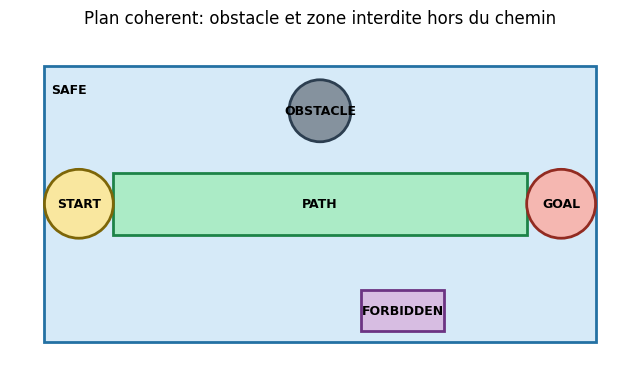

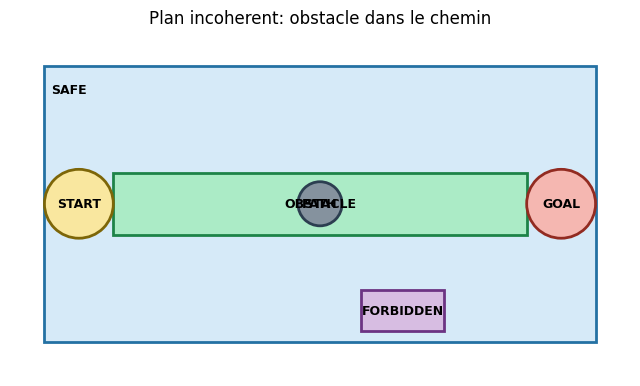

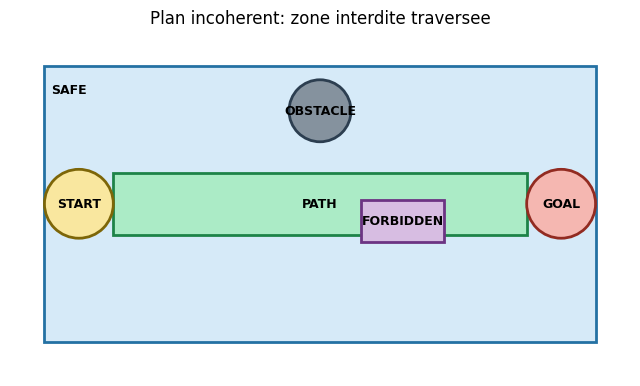

In [2]:
def draw_plan(title, obstacle_on_path=False, forbidden_on_path=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.add_patch(Rectangle((0, 0), 8, 4, facecolor="#D6EAF8", edgecolor="#2471A3", linewidth=2, label="SAFE"))
    ax.add_patch(Rectangle((1, 1.55), 6, 0.9, facecolor="#ABEBC6", edgecolor="#1D8348", linewidth=2, label="PATH"))
    ax.add_patch(Circle((0.5, 2), 0.5, facecolor="#F9E79F", edgecolor="#7D6608", linewidth=2, label="START"))
    ax.add_patch(Circle((7.5, 2), 0.5, facecolor="#F5B7B1", edgecolor="#922B21", linewidth=2, label="GOAL"))

    obstacle_x, obstacle_y = (4, 2) if obstacle_on_path else (4, 3.35)
    obstacle_radius = 0.32 if obstacle_on_path else 0.45
    forbidden_x, forbidden_y = (5.2, 1.75) if forbidden_on_path else (5.2, 0.45)
    ax.add_patch(Circle((obstacle_x, obstacle_y), obstacle_radius, facecolor="#85929E", edgecolor="#2C3E50", linewidth=2, label="OBSTACLE"))
    ax.add_patch(Rectangle((forbidden_x - 0.6, forbidden_y - 0.3), 1.2, 0.6, facecolor="#D7BDE2", edgecolor="#6C3483", linewidth=2, label="FORBIDDEN"))

    labels = {
        "SAFE": (0.35, 3.65),
        "PATH": (4, 2),
        "START": (0.5, 2),
        "GOAL": (7.5, 2),
        "OBSTACLE": (obstacle_x, obstacle_y),
        "FORBIDDEN": (forbidden_x, forbidden_y),
    }
    for label, (x, y) in labels.items():
        ax.text(x, y, label, ha="center", va="center", fontsize=9, weight="bold")

    ax.set_title(title)
    ax.set_xlim(-0.5, 8.5)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()


draw_plan("Plan coherent: obstacle et zone interdite hors du chemin")
draw_plan("Plan incoherent: obstacle dans le chemin", obstacle_on_path=True)
draw_plan("Plan incoherent: zone interdite traversee", forbidden_on_path=True)

## 2. Plan coherent

Contraintes qualitatives:

- `PATH NTPP SAFE`: le chemin est strictement dans la zone sure;
- `START EC PATH`: le depart touche le chemin;
- `GOAL EC PATH`: l'objectif touche le chemin;
- `OBSTACLE NTPP SAFE`: l'obstacle est strictement dans la zone sure;
- `OBSTACLE DC PATH`: l'obstacle est deconnecte du chemin;
- `FORBIDDEN NTPP SAFE`: la zone interdite est dans la zone sure;
- `PATH DC FORBIDDEN`: le chemin evite la zone interdite.

In [3]:
regions = ("SAFE", "PATH", "START", "GOAL", "OBSTACLE", "FORBIDDEN")

coherent_constraints = [
    ("PATH", "NTPP", "SAFE"),
    ("START", "EC", "PATH"),
    ("GOAL", "EC", "PATH"),
    ("OBSTACLE", "NTPP", "SAFE"),
    ("OBSTACLE", "DC", "PATH"),
    ("OBSTACLE", "DC", "START"),
    ("OBSTACLE", "DC", "GOAL"),
    ("FORBIDDEN", "NTPP", "SAFE"),
    ("PATH", "DC", "FORBIDDEN"),
    ("START", "DC", "FORBIDDEN"),
    ("GOAL", "DC", "FORBIDDEN"),
    ("OBSTACLE", "DC", "FORBIDDEN"),
]

ok, coherent_solver = check_plan("Plan 1", regions, coherent_constraints)
assert ok is True

Plan 1: plan coherent


## 3. Relations deduites

Le solveur ne se contente pas de verifier les contraintes donnees: il reduit aussi les relations possibles entre regions non directement contraintes.

In [4]:
interesting_pairs = [
    ("PATH", "SAFE"),
    ("SAFE", "PATH"),
    ("START", "SAFE"),
    ("GOAL", "SAFE"),
    ("OBSTACLE", "SAFE"),
    ("FORBIDDEN", "SAFE"),
    ("PATH", "FORBIDDEN"),
]

for left, right in interesting_pairs:
    print(f"R({left},{right}) = {fmt(coherent_solver.R[(left, right)])}")

assert coherent_solver.R[("PATH", "SAFE")] == {"NTPP"}
assert coherent_solver.R[("SAFE", "PATH")] == {"NTPPI"}
assert coherent_solver.R[("OBSTACLE", "SAFE")] == {"NTPP"}
assert coherent_solver.R[("FORBIDDEN", "SAFE")] == {"NTPP"}
assert coherent_solver.R[("PATH", "FORBIDDEN")] == {"DC"}

R(PATH,SAFE) = {NTPP}
R(SAFE,PATH) = {NTPPI}
R(START,SAFE) = {PO, TPP, NTPP}
R(GOAL,SAFE) = {PO, TPP, NTPP}
R(OBSTACLE,SAFE) = {NTPP}
R(FORBIDDEN,SAFE) = {NTPP}
R(PATH,FORBIDDEN) = {DC}


## 4. Plan incoherent: obstacle dans le chemin

On modelise maintenant un obstacle dans le chemin:

- `PATH NTPP SAFE`;
- `OBSTACLE NTPP PATH`;
- donc l'obstacle est aussi dans `SAFE`;
- mais on impose `OBSTACLE DC SAFE`.

Cette derniere contrainte rend le plan impossible.

In [5]:
incoherent_constraints = [
    ("PATH", "NTPP", "SAFE"),
    ("OBSTACLE", "NTPP", "PATH"),
    ("OBSTACLE", "DC", "SAFE"),
]

ok, bad_solver = check_plan("Plan 2", regions, incoherent_constraints)
assert ok is False

Plan 2: plan incoherent
Diagnostic: Inconsistency detected between SAFE and OBSTACLE


## 5. Plan incoherent: zone interdite traversee

On teste maintenant un chemin qui traverse une zone interdite. Le chemin est dans `SAFE`, la zone interdite est aussi dans `SAFE`, mais on impose a la fois:

- `PATH PO FORBIDDEN`: le chemin chevauche la zone interdite;
- `PATH DC FORBIDDEN`: le plan exige pourtant que le chemin l'evite.

Ces deux contraintes sont incompatibles.

In [6]:
forbidden_crossing_constraints = [
    ("PATH", "NTPP", "SAFE"),
    ("FORBIDDEN", "NTPP", "SAFE"),
    ("PATH", "PO", "FORBIDDEN"),
    ("PATH", "DC", "FORBIDDEN"),
]

ok, forbidden_solver = check_plan("Plan 3", regions, forbidden_crossing_constraints)
assert ok is False

Plan 3: plan incoherent
Diagnostic: Inconsistency detected between PATH and FORBIDDEN


## 6. Selection de plans candidats

On peut utiliser le raisonneur comme filtre: seuls les plans spatialement coherents sont acceptes.

In [7]:
candidate_plans = {
    "chemin_libre": coherent_constraints,
    "obstacle_dans_chemin": incoherent_constraints,
    "zone_interdite_traversee": forbidden_crossing_constraints,
    "objectif_mal_place": [
        ("PATH", "NTPP", "SAFE"),
        ("GOAL", "DC", "SAFE"),
        ("GOAL", "EC", "PATH"),
    ],
}

accepted = []
for name, constraints in candidate_plans.items():
    ok, _ = check_plan(name, regions, constraints)
    if ok:
        accepted.append(name)

print("Plans acceptes:", accepted)
assert accepted == ["chemin_libre"]

chemin_libre: plan coherent
obstacle_dans_chemin: plan incoherent
Diagnostic: Inconsistency detected between SAFE and OBSTACLE
zone_interdite_traversee: plan incoherent
Diagnostic: Inconsistency detected between PATH and FORBIDDEN
objectif_mal_place: plan incoherent
Diagnostic: Inconsistency detected between SAFE and GOAL
Plans acceptes: ['chemin_libre']


## 7. A retenir

- RCC8 permet de verifier un plan meme sans coordonnees precises.
- Les contraintes qualitatives suffisent a detecter certains plans impossibles: obstacle sur le chemin, zone interdite traversee, objectif hors zone sure.
- Le raisonneur peut servir de filtre avant une planification geometrique plus fine.
- Cette approche est adaptee aux descriptions symboliques de zones: obstacle, couloir, objectif, zone interdite.